In [2]:
from sklearn.model_selection import train_test_split

In [4]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
gdf = gpd.read_file(data_path)

In [5]:
gdf 

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,b_std,b_var,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,34429.374,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,973.742726,127.326987,128.0,24.155410,583.483815,88.046773,89.0,28.192019,794.789929,"POLYGON ((-72.97056 10.61903, -72.97054 10.619..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,6784.769,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1089.955725,112.434591,109.0,31.271098,977.881567,92.731403,91.0,29.475412,868.799885,"POLYGON ((-72.96914 10.61884, -72.96915 10.618..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12227.436,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1071.313121,127.324138,128.0,29.872697,892.378055,68.139833,62.0,38.685957,1496.603306,"POLYGON ((-72.96928 10.61948, -72.96931 10.619..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,19385.187,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1080.185062,127.948752,128.0,23.740170,563.595648,84.136398,81.0,32.283869,1042.248166,"POLYGON ((-72.97264 10.61976, -72.97273 10.619..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5013.914,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1069.046431,110.251933,110.0,33.226429,1103.995562,56.357108,53.0,27.970275,782.336267,"POLYGON ((-72.96917 10.62053, -72.9691 10.6204..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1528.937,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,936.320508,103.539958,110.0,29.934403,896.068492,53.912820,55.0,23.200185,538.248594,"POLYGON ((-75.123 3.80901, -75.12297 3.809, -7..."
1960,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,936.250000,70.500000,78.0,31.951787,1020.916667,43.055556,43.5,21.879651,478.719136,"POLYGON ((-75.12391 3.81075, -75.1239 3.81076,..."
1961,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10536.989,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,1058.363119,66.563878,68.0,29.660503,879.745450,38.797581,34.0,26.099047,681.160241,"POLYGON ((-75.12278 3.8104, -75.12282 3.81044,..."
1962,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5139.198,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,734.422016,75.457244,77.0,23.985616,575.309798,48.630724,49.0,21.899011,479.566690,"POLYGON ((-75.12367 3.81079, -75.12357 3.81077..."


In [4]:
gdf.columns

Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_median', 'r_std', 'r_var', 'g_mean', 'g_median', 'g_std', 'g_var',
       'b_mean', 'b_median', 'b_std', 'b_var', 'geometry'],
      dtype='object')

In [5]:
na_count = gdf['OBSERV'].isna().sum()
print(f"Number of NA values in 'OBSERV' column: {na_count}")


Number of NA values in 'OBSERV' column: 1


In [6]:
gdf = gdf.dropna(subset=['OBSERV'])

In [7]:
na_count = gdf['OBSERV'].isna().sum()
print(f"Number of NA values in 'OBSERV' column: {na_count}")

Number of NA values in 'OBSERV' column: 0


In [8]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std']
na_count = gdf[features].isna().sum()
print(f"Number of NA values in 'features' column: {na_count}")

Number of NA values in 'features' column: r_mean      35
r_median    35
r_std       35
r_var       35
g_mean      35
g_median    35
g_std       35
g_var       35
b_mean      35
b_median    35
b_var       35
b_std       35
dtype: int64


In [9]:
gdf = gdf.dropna(subset=['r_mean'])

In [10]:
print(gdf['CODIGO'].value_counts())

CODIGO
0       665
231     316
311     157
333     144
112     138
233     125
232      64
313      58
22       57
21       42
122      33
511      23
111      17
312      17
512      14
323      14
3212     13
32       10
331       6
334       4
121       4
3211      3
513       3
31        1
Name: count, dtype: int64


In [8]:
label_map = {
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
}

gdf['OBSERV_GROUP'] = gdf['CODIGO_GROUP'].replace(label_map)

<Axes: xlabel='OBSERV_GROUP'>

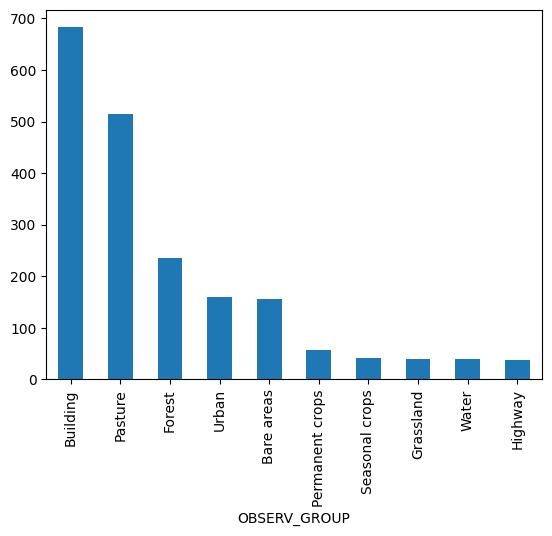

In [11]:
gdf['CODIGO_GROUP'] = gdf['CODIGO'].astype(str).str[:2]
gdf['OBSERV_GROUP'].value_counts().plot(kind='bar')

In [10]:
print(gdf['OBSERV'].value_counts())

OBSERV
building                        683
clean pasture                   322
dense forest                    158
Bare areas                      145
urban not continuous            142
weedy pasture                   128
wooded pasture                   64
fragmented forest                59
permanent crops                  57
seasonal crops                   42
highway                          33
rivers                           23
Open forest                      18
urban                            17
lakes                            14
Secondary vegetation             14
Open grassland                   13
Shrubland                        10
Sandy areas                       6
Burnt areas                       4
comercial or industrial area      4
Dense grassland                   3
canals                            3
forest                            1
Name: count, dtype: int64


#### Cleanup : 
since we observed that those are the last categories with <10 features hence we will drop them because they are too small no of samples for model to generalize 

In [13]:
gdf['area'] = gdf.to_crs(3857).geometry.area

### Train Split : 

We will use **stratify** , because we care about the distribution in class , just to make sure the class distribution is there in the test set as well 

train set distribution:
OBSERV_GROUP
Building           546
Pasture            411
Forest             189
Urban              127
Bare areas         124
Permanent crops     46
Seasonal crops      34
Water               32
Grassland           32
Highway             30
Name: count, dtype: int64

 test distribution:
OBSERV_GROUP
Building           137
Pasture            103
Forest              47
Urban               32
Bare areas          31
Permanent crops     11
Seasonal crops       8
Water                8
Grassland            8
Highway              8
Name: count, dtype: int64


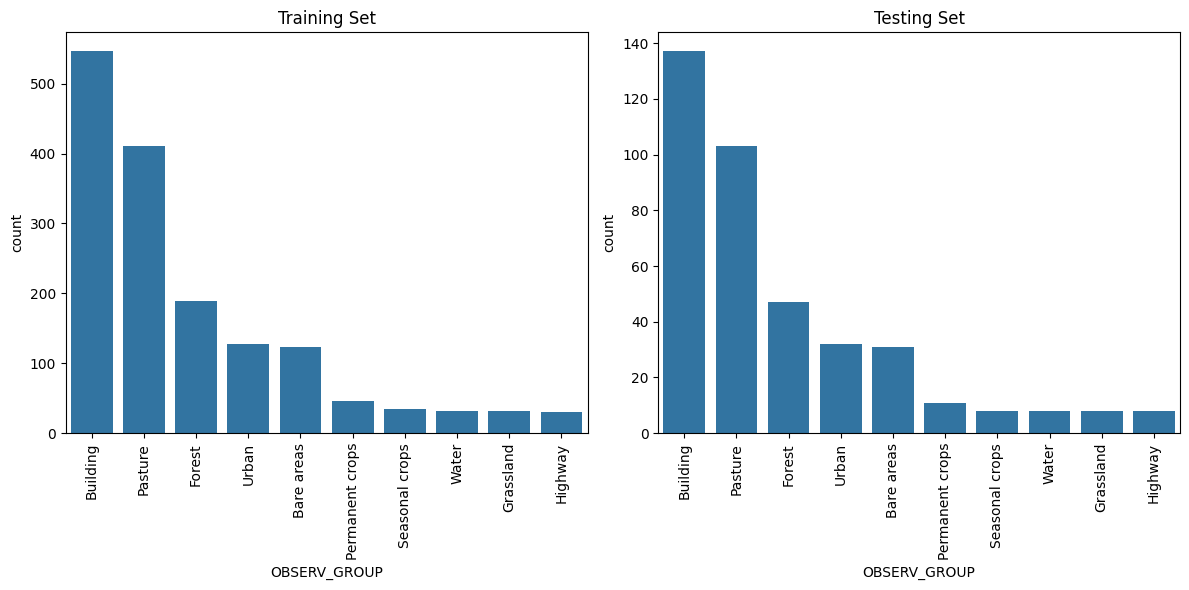

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'OBSERV_GROUP'
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std','area']

train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[target])

print("train set distribution:")
print(train_gdf[target].value_counts())
print("\n test distribution:")
print(test_gdf[target].value_counts())


class_order = train_gdf[target].value_counts().index

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x=target, data=train_gdf, ax=ax[0], order=class_order)
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Training Set")

sns.countplot(x=target, data=test_gdf, ax=ax[1], order=class_order)
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Testing Set")

plt.tight_layout()
plt.show()

In [ ]:
test_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))
train_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

### Spatially Stratified Sampling ?

We think as there are features spatially correlated , may be worth doing the spatial stratified sampling 

In [22]:
train_gdf[features]

,r_mean,r_median,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,b_var,b_std,area
1084,208.133822,233.0,57.136494,3264.578926,205.605074,227.0,54.732962,2995.697165,190.791912,214.0,3739.622993,61.152457,54.139512
396,114.827518,119.0,64.722609,4189.016147,128.036882,129.0,65.329558,4267.951132,117.081532,107.0,6591.027328,81.185142,104.680054
137,173.530540,202.0,73.300647,5372.984888,176.645139,207.0,77.495977,6005.626445,178.040137,217.0,6781.230110,82.348225,283.000199
1389,96.833264,94.0,39.828468,1586.306861,109.128906,109.0,39.064442,1526.030626,58.886060,54.0,1247.514251,35.320168,14940.149489
623,114.464414,113.0,47.329765,2240.106690,123.623597,130.0,36.791095,1353.584665,77.938724,78.0,1055.881557,32.494331,3840.901611
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,206.543019,236.0,58.454599,3416.940109,219.875190,247.0,53.746206,2888.654662,214.689229,249.0,4194.572925,64.765523,24.848614
664,126.569305,123.0,39.021389,1522.668775,132.139372,133.0,31.927362,1019.356443,89.507846,87.0,805.608281,28.383239,278.316951
766,155.889617,157.0,50.859625,2586.701480,158.537087,157.0,41.192116,1696.790387,108.309472,92.0,3088.117043,55.570829,151.513593
1447,103.974448,105.0,29.335366,860.563679,117.447445,119.0,30.361819,921.840039,56.179153,55.0,540.221410,23.242664,34037.140830


In [23]:
test_gdf[features]

,r_mean,r_median,r_std,r_var,g_mean,g_median,g_std,g_var,b_mean,b_median,b_var,b_std,area
189,209.842108,235.0,56.405235,3181.550505,215.251759,246.0,58.857142,3464.163108,217.176922,251.0,3672.077877,60.597672,16.881504
972,172.106141,180.0,35.726801,1276.404315,189.003401,204.0,35.625265,1269.159521,189.531541,210.0,1709.376901,41.344612,40.673357
1176,169.186053,204.0,71.615130,5128.726872,164.075252,182.0,64.124714,4111.978974,165.477083,188.0,4482.021223,66.947899,598.014800
1852,129.676551,140.0,38.733380,1500.274735,118.839881,129.0,42.042603,1767.580439,109.303006,113.0,2281.023361,47.760060,189.037070
1552,115.953335,118.0,29.588005,875.450013,141.329024,144.0,28.595190,817.684864,92.193392,91.0,519.136737,22.784572,5808.962255
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,107.434949,108.0,21.107432,445.523681,116.910780,118.0,19.493799,380.008213,67.237877,67.0,367.670810,19.174744,185065.347794
969,117.314502,120.0,42.670445,1820.766899,143.325772,145.0,38.494051,1481.791956,94.154177,96.0,1372.387109,37.045743,1663.082843
1391,92.411471,90.0,33.098067,1095.482064,111.421890,110.0,35.216636,1240.211483,46.496738,43.0,669.961740,25.883619,947.298318
1752,159.629191,168.0,52.557811,2762.323524,145.039956,151.0,57.068602,3256.825280,136.702180,136.0,3938.518294,62.757615,389.024538
